In [1]:
%load_ext autoreload
%autoreload 2
from qm.QuantumMachinesManager import QuantumMachinesManager
import qm.qua as q
from qualang_tools.results import progress_counter, fetching_tool
from importlib import reload
from jobqueue import JobQueue
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import json
from qm import SimulationConfig
import opx_config_xiayu11_latest as cf
import func
from qualang_tools.units import unit as u

reload(cf)
config = cf.config

# Load IQ blob calibration
with open('Q1Q2_IQ_blobs.json', 'r') as f:
    calib = json.load(f)

angle1     = calib['Q1_readout_rotation_angle']
threshold1 = calib['Q1_readout_threshold']
angle2     = calib['Q2_readout_rotation_angle']
threshold2 = calib['Q2_readout_threshold']

print("=== Loaded IQ Blob Calibration ===")
print(f"Q1 angle: {np.degrees(angle1):.2f} deg  threshold: {threshold1:.6e}")
print(f"Q2 angle: {np.degrees(angle2):.2f} deg  threshold: {threshold2:.6e}")


2026-03-12 13:53:59,109 - qm - INFO     - Starting session: 43eb757b-c4dc-4599-9b84-b747861f0e3f


C:\Users\crow104e3\AppData\Local\Temp\ipykernel_2552\2614770205.py:3: DeprecationWarning: 'qm.QuantumMachinesManager.QuantumMachinesManager' is moved as of 1.1.2 and will be removed in 1.2.0. use 'qm.QuantumMachinesManager' instead
  from qm.QuantumMachinesManager import QuantumMachinesManager


=== Loaded IQ Blob Calibration ===
Q1 angle: 189.28 deg  threshold: -6.643606e-04
Q2 angle: 109.29 deg  threshold: 3.721877e-03


In [2]:
##################
#   Parameters   #
##################
n_avgs   = 100    # averages per (T, experiment) point
amp      = 0.85    # readout amplitude scale

# Sweep T: free evolution time on Q1 AFTER Q2's pulse(s) finish
# In clock cycles (1 cc = 4 ns)
T_min_cc  = 4
T_max_cc  = 750
T_step_cc = 2

T_arr    = np.arange(T_min_cc, T_max_cc, T_step_cc)
T_arr_ns = T_arr * 4
n_T      = len(T_arr)

print(f"Sweeping T: {T_arr_ns[0]} to {T_arr_ns[-1]} ns in {n_T} steps ({T_step_cc*4} ns/step)")
print(f"Total shots: {n_avgs * n_T * 2:,}  (x2 for exp1/exp2)")

detuning = 5e5

Sweeping T: 16 to 2992 ns in 373 steps (8 ns/step)
Total shots: 74,600  (x2 for exp1/exp2)


In [3]:
def opx_machine():
    with JobQueue('Emily', message='Ramsey TOF clock', total=n_avgs) as jq:
        func.update_twpa_params(cf)
        qmManager = QuantumMachinesManager(cf.qop_ip, cf.port)

        
        try:
            qm = qmManager.open_qm(config, close_other_machines=True)

                
            func.bnc_on(cf)
            time.sleep(1)

            with q.program() as prog:

                I_1 = q.declare(q.fixed)
                Q_1 = q.declare(q.fixed)
                I_rot_1 = q.declare(q.fixed)

                I_2 = q.declare(q.fixed)
                Q_2 = q.declare(q.fixed)
                I_rot_2 = q.declare(q.fixed)

                n = q.declare(int)
                T = q.declare(int)   # swept free evolution (cc)
                a = q.declare(int)   # 0 = Exp1 (ref), 1 = Exp2 (feedback)

                st_I1 = q.declare_stream()
                st_I2 = q.declare_stream()
                st_T = q.declare_stream()
                st_a = q.declare_stream()
                st_n = q.declare_stream()

                q.update_frequency('Q1_DL', int(cf.if_Q1 + detuning))


                with q.for_(T, T_min_cc, T < T_max_cc, T + T_step_cc):
                    with q.for_(a, 0, a < 2, a + 1):
                        with q.for_(n, 0, n < n_avgs, n + 1):

                            # STEP 1: Q1 first pi/2 + Q2 measurement fire together 
                            q.align('Q1_DL', 'Q2_DL', 'res_1', 'res_2')
                            #q.align('Q1_DL', 'Q2_DL')

                            q.set_dc_offset('res_2', 'I', cf.DC_offset9_readout)
                            q.set_dc_offset('res_2', 'Q', cf.DC_offset10_readout)
                            #q.align()

                            q.play('x90', 'Q1_DL')
                            q.measure(
                                'readout_4us' * q.amp(amp), 'res_2', None,
                                q.dual_demod.full('cos',       'out1', 'sin', 'out2', I_2),
                                q.dual_demod.full('minus_sin', 'out1', 'cos', 'out2', Q_2),
                            )
                            q.set_dc_offset('res_2', 'I', cf.DC_offset9)
                            q.set_dc_offset('res_2', 'Q', cf.DC_offset10)

                            # Rotate Q2 result onto discriminator axis
                            q.assign(I_rot_2,
                                I_2 * q.Math.cos(angle2) + Q_2 * q.Math.sin(angle2))

                            # STEP 2: Exp-dependent action on Q2 
                            # Exp 1 (a=0): Q2 measurement ends, T starts immediately
                            # Exp 2 (a=1): conditional pi, THEN T starts
                            with q.if_(a == 1):
                                
                                #q.play('x180', 'Q2_DL')
                                #q.wait(64, 'Q2_DL')
                                # flip Q2 to ground if measured |e>'''
                                with q.if_(I_rot_2 > threshold2):
                                    q.play('x180', 'Q2_DL')
                                    #q.wait(64, 'Q2_DL')   # let qubit settle

                            # STEP 3: Align then wait T 
                            #q.align('Q1_DL', 'Q2_DL', 'res_1', 'res_2') 
                            q.align('Q1_DL', 'Q2_DL')
                            q.wait(T, 'Q1_DL')

                            #  STEP 4: Q1 second pi/2 
                            q.play('x90', 'Q1_DL')

                            # STEP 5: Read out both qubits
                            #q.align('Q1_DL', 'Q2_DL', 'res_1', 'res_2')
                            q.align('Q1_DL', 'Q2_DL')

                            q.set_dc_offset('res_1', 'I', cf.DC_offset9_readout)
                            q.set_dc_offset('res_1', 'Q', cf.DC_offset10_readout)
                            q.align()

                            q.measure(
                                'readout_4us' * q.amp(amp), 'res_1', None,
                                q.dual_demod.full('cos',       'out1', 'sin', 'out2', I_1),
                                q.dual_demod.full('minus_sin', 'out1', 'cos', 'out2', Q_1),
                            )

                            q.set_dc_offset('res_1', 'I', cf.DC_offset9)
                            q.set_dc_offset('res_1', 'Q', cf.DC_offset10)

                            q.assign(I_rot_1,
                                I_1 * q.Math.cos(angle1) + Q_1 * q.Math.sin(angle1))

                            # Save
                            q.save(I_rot_1, st_I1)
                            q.save(I_rot_2, st_I2)   # Q2 state at readout (post-feedback)
                            q.save(T, st_T)
                            q.save(a, st_a)
                            q.save(n, st_n)

                            q.wait(75000, 'res_1', 'res_2')

                with q.stream_processing():
                    st_I1.save_all('I_rot_1')
                    st_I2.save_all('I_rot_2')
                    st_T.save_all('T_cc')
                    st_a.save_all('exp_label')
                    st_n.save('iteration')

            job = qm.execute(prog)
            ###########################
            # Run or Simulate Program #
            ###########################
            simulate = False
                
            if simulate:
                simulation_config = SimulationConfig(duration=200000)
                job = qmManager.simulate(config, prog, simulation_config)
                samples = job.get_simulated_samples()
                samples.con1.plot()

            iteration = 0
            my_results = fetching_tool(
                job,
                ['I_rot_1', 'I_rot_2', 'T_cc', 'exp_label', 'iteration'],
                mode='live'
            )

            while my_results.is_processing() and iteration < n_avgs:
                I1, I2, T_vals, exp_labels, iteration_new = my_results.fetch_all()
                progress_counter(iteration_new, n_avgs, start_time=my_results.start_time)
                jq.update(iteration_new - iteration)
                iteration = iteration_new

        finally:
            func.bnc_off()
            print(job.execution_report())
            qm.close()

    return I1, I2, T_vals, exp_labels


In [4]:
I_rot_1, I_rot_2, T_cc_raw, exp_labels = opx_machine()


Done waiting.


  0%|           [time left: ?]

2026-03-12 13:54:03,186 - qm - INFO     - Performing health check


INFO:qm.api.frontend_api:Performing health check


2026-03-12 13:54:03,196 - qm - INFO     - Health check passed


...

2026-03-12 13:54:05,883 - qm - INFO     - Sending program to QOP for compilation


INFO:qm.api.frontend_api:Sending program to QOP for compilation


2026-03-12 13:54:07,418 - qm - INFO     - Executing program


INFO:qm.QuantumMachine:Executing program


Progress: [##################################################] 100.0% --> elapsed time: 2.15s
Progress: [##################################################] 100.0% --> elapsed time: 2.38s
Progress: [##################################################] 100.0% --> elapsed time: 18.62s
Progress: [##################################################] 100.0% --> elapsed time: 22.97s
Progress: [##################################################] 100.0% --> elapsed time: 23.05s
Execution report for job 1772946636131
No errors
Job finished.


In [10]:
# Data comes back as (T, a, n)
mask_exp1 = (exp_labels == 0)
mask_exp2 = (exp_labels == 1)

T_exp1 = T_cc_raw[mask_exp1] * 4   # ns
T_exp2 = T_cc_raw[mask_exp2] * 4

I1_exp1 = I_rot_1[mask_exp1]
I1_exp2 = I_rot_1[mask_exp2]

I2_exp1 = I_rot_2[mask_exp1]   # Q2 state pre-feedback (Exp1)
I2_exp2 = I_rot_2[mask_exp2]   # Q2 state post-feedback (Exp2)

# Average Q1 Ramsey signal per T point for each experiment
T_unique = np.unique(T_exp1)
fringe_exp1 = np.array([I1_exp1[T_exp1 == t].mean() for t in T_unique])
#fringe_exp2 = np.array([I1_exp2[T_exp2 == t].mean() for t in T_unique])

# Post-select Exp2: only shots where Q2 was measured excited (feedback actually fired)
q2_excited_mask = I2_exp2 < threshold2   # |e> condition (assuming your threshold convention)

T_exp2_ps = T_exp2[q2_excited_mask]
I1_exp2_ps = I1_exp2[q2_excited_mask]
print(len(I1_exp2_ps))

# Recompute fringe with post-selection
fringe_exp2_ps = np.array([I1_exp2_ps[T_exp2_ps == t].mean() for t in T_unique])
n_excited_per_T = np.array([(q2_excited_mask & (T_exp2 == t)).sum() for t in T_unique])
print(f"Mean shots per T point after post-selection: {n_excited_per_T.mean():.1f}")

# Q2 ground state fraction per T (Exp2 only — shows feedback worked)
q2_gnd_exp2 = np.array([(I2_exp2[T_exp2 == t] < threshold2).mean() for t in T_unique])

print(f"Points per experiment: {len(T_unique)}")
print(f"Q2 mean ground fraction after feedback: {q2_gnd_exp2.mean()*100:.1f}%")


37126
Mean shots per T point after post-selection: 99.5
Points per experiment: 373
Q2 mean ground fraction after feedback: 99.5%


In [6]:
def ramsey_fringe(t, A, f, phi, offset):
    return A * np.cos(2 * np.pi * f * t + phi) + offset

def fit_fringe(T_ns, fringe, label):
    # Rough initial guess from FFT
    fft = np.fft.rfft(fringe - fringe.mean())
    freqs = np.fft.rfftfreq(len(fringe), d=(T_ns[1]-T_ns[0]))
    f0 = freqs[np.argmax(np.abs(fft[1:])) + 1]
    A0 = (fringe.max() - fringe.min()) / 2

    try:
        popt, pcov = curve_fit(
            ramsey_fringe, T_ns, fringe,
            p0=[A0, f0, 0.0, fringe.mean()],
            maxfev=10000
        )
        perr = np.sqrt(np.diag(pcov))
        print(f"{label}: A={popt[0]:.4f}, f={popt[1]*1e3:.4f} MHz, "
              f"phi={np.degrees(popt[2]):.2f} deg, offset={popt[3]:.4f}")
        return popt, perr
    except RuntimeError:
        print(f"{label}: fit failed")
        return None, None

popt1, perr1 = fit_fringe(T_unique, fringe_exp1, 'Exp1 (ref)')
popt2, perr2 = fit_fringe(T_unique, fringe_exp2_ps, 'Exp2 (feedback)')

if popt1 is not None and popt2 is not None:
    dphi_deg = np.degrees(popt2[2] - popt1[2])
    # Convert phase shift to time using fitted frequency
    f_avg_GHz = (popt1[1] + popt2[1]) / 2
    if f_avg_GHz > 0:
        tof_ns = (popt2[2] - popt1[2]) / (2 * np.pi * f_avg_GHz)
        print(f"\n###Time of Flight Result###")
        print(f"Phase offset:       {dphi_deg:.2f} deg")
        print(f"Ramsey frequency:   {f_avg_GHz*1e3:.4f} MHz")
        print(f"Feedback time:   {tof_ns:.1f} ns  ({tof_ns/4:.1f} clock cycles)")


Exp1 (ref): A=0.0009, f=0.5976 MHz, phi=-41.11 deg, offset=-0.0014
Exp2 (feedback): A=0.0009, f=0.5936 MHz, phi=-25.31 deg, offset=-0.0014

###Time of Flight Result###
Phase offset:       15.81 deg
Ramsey frequency:   0.5956 MHz
Feedback time:   73.7 ns  (18.4 clock cycles)


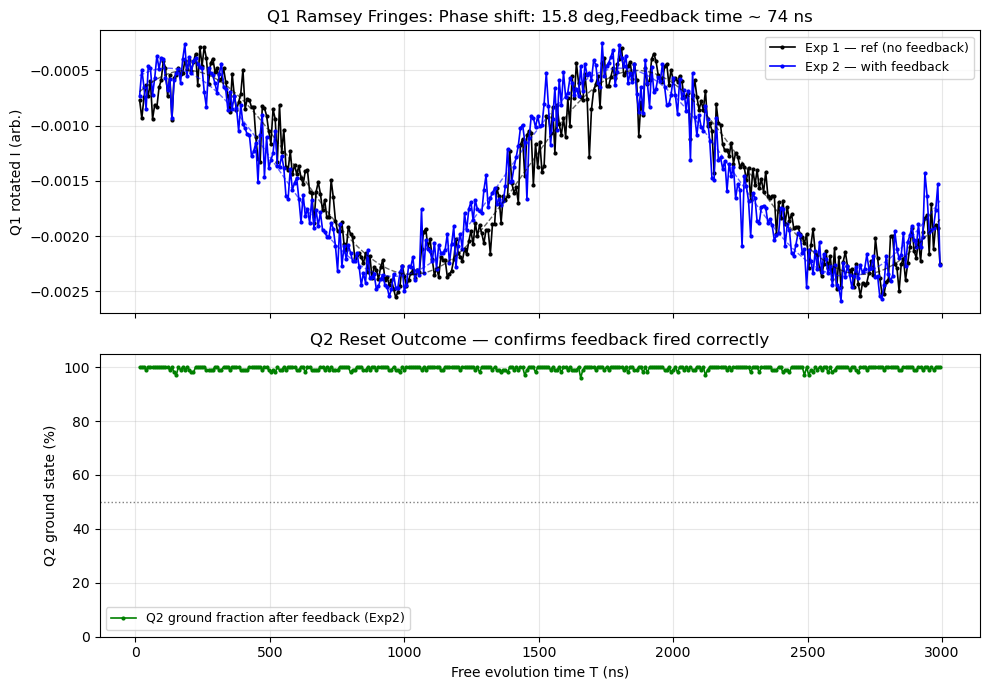

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# #### Panel 1: Ramsey fringes ##########################################──────
ax = axes[0]
ax.plot(T_unique, fringe_exp1, 'k.-', lw=1.2, ms=4, label='Exp 1 — ref (no feedback)')
ax.plot(T_unique, fringe_exp2_ps, 'b.-', lw=1.2, ms=4, label='Exp 2 — with feedback')

# Overlay fits
T_fine = np.linspace(T_unique[0], T_unique[-1], 500)
if popt1 is not None:
    ax.plot(T_fine, ramsey_fringe(T_fine, *popt1), 'k--', lw=1, alpha=0.6)
if popt2 is not None:
    ax.plot(T_fine, ramsey_fringe(T_fine, *popt2), 'b--', lw=1, alpha=0.6)

if popt1 is not None and popt2 is not None:
    ax.set_title(
        f'Q1 Ramsey Fringes: Phase shift: {dphi_deg:.1f} deg,'
        f'Feedback time ~ {tof_ns:.0f} ns'
    )
else:
    ax.set_title('Q1 Ramsey Fringes (Exp 1 vs Exp 2)')

ax.set_ylabel('Q1 rotated I (arb.)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ##### Panel 2: Q2 state after feedback ##########################################
ax = axes[1]
ax.plot(T_unique, q2_gnd_exp2 * 100, 'g.-', lw=1.2, ms=4,
        label='Q2 ground fraction after feedback (Exp2)')
ax.axhline(50, color='gray', ls=':', lw=1)
ax.set_ylabel('Q2 ground state (%)')
ax.set_xlabel('Free evolution time T (ns)')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_title('Q2 Reset Outcome — confirms feedback fired correctly')

plt.tight_layout()
plt.show()


In [8]:
print(f"Exp1 phase: {popt1[2]:.6f} rad  ({np.degrees(popt1[2]):.2f} deg)")
print(f"Exp2 phase: {popt2[2]:.6f} rad  ({np.degrees(popt2[2]):.2f} deg)")
print(f"Difference: {popt2[2] - popt1[2]:.6f} rad  ({np.degrees(popt2[2] - popt1[2]):.2f} deg)")
print(f"Feedback time: {tof_ns:.1f} ns ({tof_ns/4:.1f} cc)")

Exp1 phase: -0.717590 rad  (-41.11 deg)
Exp2 phase: -0.441658 rad  (-25.31 deg)
Difference: 0.275932 rad  (15.81 deg)
Feedback time: 73.7 ns (18.4 cc)
